In [275]:
import sys
# на уровень выше из research_rank/
sys.path.insert(0, '..')
from Tomography_qutrit import*
import matplotlib.pyplot as plt

### Попробуем сначала замоделировать смешивания двух состояний и их восстановление

Для начала рассмотрим идеальные случай

In [2]:
protocol = [Gl_4(0), Gl_4(pi / 8), Gl_4(3 * pi / 8), Gl_4(5 * pi / 8), Gl_4(7 * pi / 8)]
tomography = tomography_pol_qutrit(protocol)
rank = 2


sigma1 = 100
sigma2 = 100
sigma3 = 100

teor_state = tomography.density(tomography.hh)
khh = (tomography.B @ teor_state.flatten().reshape(-1, 1)).flatten() 
khh = khh.reshape(-1, len(protocol)).T.flatten()

tomography.experiment(khh, teor_state, sigma1, sigma2, sigma3, rank)

Fidelity between start matrix density and matrix pseudoinversion = 1.0
Finish fidelity = 1.0


In [18]:
protocol = [Gl_4(0), Gl_4(pi / 8), Gl_4(3 * pi / 8), Gl_4(5 * pi / 8), Gl_4(7 * pi / 8)]
tomography = tomography_pol_qutrit(protocol)
rank = 2

sigma1 = 100
sigma2 = 100
sigma3 = 100

teor_state_1 = array(tomography.density(tomography.hh), complex)
teor_state_2 = array(tomography.density(tomography.vv), complex)
prob_1 = 0.35
prob_2 = 1.0 - prob_1

freq_1 = (tomography.B @ teor_state_1.flatten().reshape(-1, 1)).flatten() 
freq_1 = freq_1.reshape(-1, len(protocol)).T.flatten()
freq_2 = (tomography.B @ teor_state_2.flatten().reshape(-1, 1)).flatten() 
freq_2 = freq_2.reshape(-1, len(protocol)).T.flatten()

teor_state = prob_1 * teor_state_1 + prob_2 * teor_state_2
freq = prob_1 * freq_1 + prob_2 * freq_2

tomography.experiment(freq, teor_state, sigma1, sigma2, sigma3, rank)

Fidelity between start matrix density and matrix pseudoinversion = 1.0
Finish fidelity = 1.0000000000000009


In [51]:
protocol = [Gl_4(0), Gl_4(pi / 8), Gl_4(3 * pi / 8), Gl_4(5 * pi / 8), Gl_4(7 * pi / 8)]
tomography = tomography_pol_qutrit(protocol)
rank = 2

sigma1 = 20
sigma2 = 400
sigma3 = 700

teor_state_1 = array(tomography.density(tomography.hh), complex)
teor_state_2 = array(tomography.density(tomography.vv), complex)
prob_1 = 0.35
prob_2 = 1.0 - prob_1

freq_1 = (tomography.B @ teor_state_1.flatten().reshape(-1, 1)).flatten() 
freq_1 = freq_1.reshape(-1, len(protocol)).T.flatten()
freq_2 = (tomography.B @ teor_state_2.flatten().reshape(-1, 1)).flatten() 
freq_2 = freq_2.reshape(-1, len(protocol)).T.flatten()

teor_state = prob_1 * teor_state_1 + prob_2 * teor_state_2
freq = prob_1 * freq_1 + prob_2 * freq_2
freq[::3] = freq[::3] * sigma1
freq[1::3] = freq[1::3] * sigma2
freq[2::3] = freq[2::3] * sigma3

tomography.experiment(freq, teor_state, sigma1, sigma2, sigma3, rank)

Fidelity between start matrix density and matrix pseudoinversion = 0.9999999999999993
Finish fidelity = 0.9999999999999996


In [ ]:
protocol = [Gl_4(0), Gl_4(pi / 8), Gl_4(3 * pi / 8), Gl_4(5 * pi / 8), Gl_4(7 * pi / 8)]
tomography = tomography_pol_qutrit(protocol)
rank = 2

sigma1_1 = 20
sigma2_1 = 400
sigma3_1 = 700

sigma1_2 = 200
sigma2_2 = 1000
sigma3_2 = 70

teor_state_1 = array(tomography.density(tomography.hh), complex)
teor_state_2 = array(tomography.density(tomography.vv), complex)
prob_1 = 0.35
prob_2 = 1.0 - prob_1

freq_1 = (tomography.B @ teor_state_1.flatten().reshape(-1, 1)).flatten() 
freq_1 = freq_1.reshape(-1, len(protocol)).T.flatten()
freq_2 = (tomography.B @ teor_state_2.flatten().reshape(-1, 1)).flatten() 
freq_2 = freq_2.reshape(-1, len(protocol)).T.flatten()

teor_state = prob_1 * teor_state_1 + prob_2 * teor_state_2
freq = prob_1 * freq_1 + prob_2 * freq_2
sigma1 = prob_1 * sigma1_1 + prob_2 * sigma1_2
sigma2 = prob_1 * sigma2_1 + prob_2 * sigma2_2
sigma3 = prob_1 * sigma3_1 + prob_2 * sigma3_2
freq[::3] = freq[::3] * sigma1
freq[1::3] = freq[1::3] * sigma2
freq[2::3] = freq[2::3] * sigma3

tomography.experiment(freq, teor_state, sigma1, sigma2, sigma3, rank)

Fidelity between start matrix density and matrix pseudoinversion = 1.0
Finish fidelity = 1.0


Сделаем моделирование эксперимента

In [252]:
from numpy import random, real, isclose, clip

def probs_to_freqs(probs, N, ignore=False):
    """
    Превращает вероятности в экспериментальные частоты
    через моделирование конечной статистики.
    
    Args:
        probs (array-like): список вероятностей (сумма ≈ 1)
        N (int): общее число экспериментов (например, фотонов)
        ignore (bool): если True, то при сумме != 1 нормирует probs автоматически
    
    Returns:
        freqs (np.ndarray): массив частот (сумма ≈ 1)
        counts (np.ndarray): массив целых отсчётов
    """
    p = array(probs, dtype=float)
    
    # фиксим численные ошибки
    if ignore or not isclose(p.sum(), 1.0):
        if p.sum() <= 0:
            raise ValueError("Сумма вероятностей должна быть > 0")
        p = clip(p, 0, None)   # убираем отрицательные из-за численных артефактов
        p = p / p.sum()
    
    # моделируем эксперимент (мультиномиальное распределение)
    counts = random.multinomial(N, p)
    freqs = counts / N
    
    return freqs

protocol = [Gl_4(0), Gl_4(pi / 8), Gl_4(3 * pi / 8), Gl_4(5 * pi / 8), Gl_4(7 * pi / 8)]
tomography = tomography_pol_qutrit(protocol)
rank = 2
N = 10000

sigma1_1 = 20
sigma2_1 = 400
sigma3_1 = 700

sigma1_2 = 200
sigma2_2 = 1000
sigma3_2 = 70

teor_state_1 = array(tomography.density(tomography.hh), complex)
teor_state_2 = array(tomography.density(tomography.vv), complex)
prob_1 = 0.37
prob_2 = 1.0 - prob_1

freq_1 = (tomography.B @ teor_state_1.flatten().reshape(-1, 1)).flatten() 
freq_1 = freq_1.reshape(-1, len(protocol)).T.flatten()
for i in range(len(protocol)):
    freq_1[3 * i : 3 * (i + 1)] = probs_to_freqs(real(freq_1[3 * i : 3 * (i + 1)]), N)
freq_2 = (tomography.B @ teor_state_2.flatten().reshape(-1, 1)).flatten() 
freq_2 = freq_2.reshape(-1, len(protocol)).T.flatten()
for i in range(len(protocol)):
    freq_2[3 * i : 3 * (i + 1)] = probs_to_freqs(real(freq_2[3 * i : 3 * (i + 1)]), N)

teor_state = prob_1 * teor_state_1 + prob_2 * teor_state_2
freq = prob_1 * freq_1 + prob_2 * freq_2
sigma1 = prob_1 * sigma1_1 + prob_2 * sigma1_2
sigma2 = prob_1 * sigma2_1 + prob_2 * sigma2_2
sigma3 = prob_1 * sigma3_1 + prob_2 * sigma3_2
freq[::3] = freq[::3] * sigma1
freq[1::3] = freq[1::3] * sigma2
freq[2::3] = freq[2::3] * sigma3



tomography.experiment(freq, teor_state, sigma1, sigma2, sigma3, rank)

Fidelity between start matrix density and matrix pseudoinversion = 0.999986257573562
Finish fidelity = 0.9999961397631337


Теперь перейдём к реальным экспериментальным данным



 prob_1 * HH + prob_2 * VV  



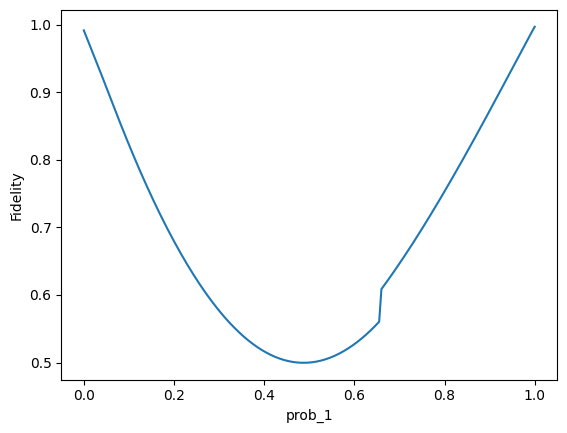

In [283]:
from numpy import linspace
protocol = [Gl_4(0), Gl_4(pi / 8), Gl_4(3 * pi / 8), Gl_4(5 * pi / 8), Gl_4(7 * pi / 8)]
tomography = tomography_pol_qutrit(protocol)
rank = 1


print("\n\n prob_1 * HH + prob_2 * VV  \n")
# # 20 повторения по 10с при HWP_p под 0
# Noise
# 1.2 3.15 233.6
# 72.7 5.35 1.15
# Калибровка      10.7 100.1 69.15
n_hh = 1.2 / 233.6
n_hv_1 = 3.15 / 233.6
n_hv_2 = 5.35 / 72.7
n_vv = 1.15 / 72.7

sigma1_1 = 10.7 - 69.15 * n_hh
sigma2_1 = (100.1 - 10.7 * n_hv_1 - 69.15 * n_hv_2)/2
sigma3_1 = 69.15 - 10.7 * n_vv

teor_state_1 = tomography.density(tomography.hh)

freq_1 = array([
72.7 - 1.15 * n_hh, 5.35 - 5.35,	1.15 - 72. * n_vv,
44.6 - 20.95 * n_hh, 58.1 - 44.6 * n_hv_1 - 20.95 * n_hv_2, 20.95 - 44.6 * n_vv,
34.55 - 12.95 * n_hh, 94.55 - 34.55 * n_hv_1 - 12.95 * n_hv_2, 12.95 - 34.55 * n_vv,
39.9 - 10.7 * n_hh, 78.3 - 39.9 * n_hv_1 - 10.7 * n_hv_2, 10.7 - 39.9 * n_vv,
37.35 - 22.3 * n_hh, 73.65 - 37.35 * n_hv_1 - 22.3 * n_hv_2, 22.3 - 37.35 * n_vv
])

n_hh = 0.45 / 186.59
n_hv_1 = 1.9 / 186.9
n_hv_2 = 4.6 / 67.85
n_vv = 1.5 / 67.85

sigma1_2 = 21.55 - 45.35 * n_hh
sigma2_2 = (92.1 - 21.55 * n_hv_1 - 45.35 * n_hv_2)/2
sigma3_2 = 45.35 - 21.55 * n_vv

teor_state_2 = tomography.density(tomography.vv)

freq_2 = array([
0.45 - 186.9 * n_hh, 1.65 - 1.65,	186.9 - 0.45 * n_vv,
3.95 - 108.6 * n_hh, 88.9 - 3.95 * n_hv_1 - 108.6 * n_hv_2, 108.6 - 3.95 * n_vv,
5.25 - 103.55 * n_hh, 91.95 - 5.25 * n_hv_1 - 103.55 * n_hv_2, 103.55 - 5.25 * n_vv,
3.1 - 108.95 * n_hh, 89.45 - 3.1 * n_hv_1 - 108.95 * n_hv_2, 108.95 - 3.1 * n_vv,
6.2 - 107.1 * n_hh, 86.35 - 6.2 * n_hv_1 - 107.1 * n_hv_2, 107.1 - 6.2 * n_vv
])

list_prob_1 = linspace(0.0, 1.0, 201)
list_fid = [0] * len(list_prob_1)

for i, prob_1 in enumerate(list_prob_1):

    prob_2 = 1.0 - prob_1

    teor_state = prob_1 * teor_state_1 + prob_2 * teor_state_2
    freq = prob_1 * freq_1 + prob_2 * freq_2
    sigma1 = prob_1 * sigma1_1 + prob_2 * sigma1_2
    sigma2 = prob_1 * sigma2_1 + prob_2 * sigma2_2
    sigma3 = prob_1 * sigma3_1 + prob_2 * sigma3_2
    # freq[::3] = freq[::3] / sigma1
    # freq[1::3] = freq[1::3] / sigma2
    # freq[2::3] = freq[2::3] / sigma3

    tomography.experiment(freq, teor_state, sigma1, sigma2, sigma3, rank, visible=False)
    list_fid[i] = abs(tomography.Fidelity(tomography.matrix_finish, tomography.start_density))

plt.plot(list_prob_1, list_fid)
plt.xlabel("prob_1")
plt.ylabel("Fidelity")
plt.show()



 prob_1 * AA + prob_2 * RR  



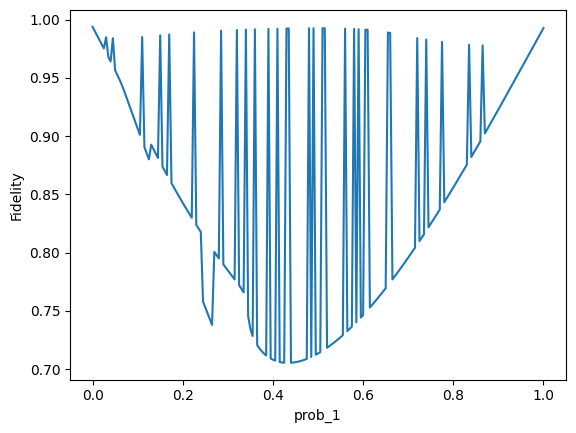

[np.float64(0.9938676149710604), np.float64(0.9901676552670603), np.float64(0.9864667293153658), np.float64(0.9827639878615179), np.float64(0.9790580579118832), np.float64(0.9753468445542541), np.float64(0.9848741993604329), np.float64(0.9678937990453582), np.float64(0.9641385534156527), np.float64(0.9840906600462932), np.float64(0.956494028411351), np.float64(0.9525304575831771), np.float64(0.94836315822189), np.float64(0.9438418106546727), np.float64(0.93886415496118), np.float64(0.9335542162098294), np.float64(0.9281192228379703), np.float64(0.9226695994991575), np.float64(0.917242489684744), np.float64(0.9118472662298396), np.float64(0.9064844093827532), np.float64(0.9011517879379985), np.float64(0.9850860988478158), np.float64(0.8905666986845279), np.float64(0.8853093821287327), np.float64(0.880072710307628), np.float64(0.892736033394892), np.float64(0.8888627278229413), np.float64(0.8850434655457861), np.float64(0.8812756846408363), np.float64(0.9865660442670136), np.float64(0.87

In [294]:

rank = 1

print("\n\n prob_1 * AA + prob_2 * RR  \n")


n_hh =  0.1 / 177.8
n_hv_1 = 4.1 / 177.8
n_hv_2 = 5.45 / 45.9
n_vv = 0.65 / 45.9

sigma1_1 = 12.45 - 39.05 * n_hh
sigma2_1 = (134.2 - 12.45 * n_hv_1 - 39.05 * n_hv_2)/2
sigma3_1 = 39.05 - 12.45 * n_vv

teor_state_1 = tomography.density(tomography.aa)

freq_1 = array([
12.45 - 39.05 * n_hh, 134.2 - 12.45 * n_hv_1 - 39.05 * n_hv_2,	39.05 - 12.45 * n_vv,
3.2 - 99.5 * n_hh, 108.05 - 3.2 * n_hv_1 - 99.5 * n_hv_2, 99.5 - 3.2 * n_vv,
26.4 - 13.8 * n_hh, 114.5 - 26.4 * n_hv_1 - 13.8 * n_hv_2, 13.8 - 26.4 * n_vv,
4.2 - 78.9 * n_hh, 143.6 - 4.2  * n_hv_1 - 78.9 * n_hv_2, 78.9 - 4.2  * n_vv,
29.7 - 6.4 * n_hh, 116.75 - 29.7 * n_hv_1 - 6.4 * n_hv_2, 6.4 - 29.7 * n_vv
])

n_hh = 0 / 154
n_hv_1 = 4 / 154
n_hv_2 = 7.45 / 42.2
n_vv = 0.4 / 42.2

sigma1_2 = 9.75 - 29.55 * n_hh
sigma2_2 = (131.7 - 9.75 * n_hv_1 - 29.55 * n_hv_2)/2
sigma3_2 = 29.55 - 9.75 * n_vv

teor_state_2 = tomography.density(tomography.rr)

freq_2 = array([
9.75 - 29.55 * n_hh, 131.7 - 9.75 * n_hv_1 - 29.55 * n_hv_2,	29.55 - 9.75 * n_vv,
30.2 - 4.35 * n_hh, 51.1 - 30.2 * n_hv_1 - 4.35 * n_hv_2, 4.35 - 30.2 * n_vv,
28.1 - 2.25 * n_hh, 75.05 - 28.1 * n_hv_1 - 2.25 * n_hv_2, 2.25 - 28.1 * n_vv,
0.4 - 125.9 * n_hh, 43.2 - 0.4 * n_hv_1 - 125.9  * 0, 125.9  - 0.4  * n_vv,
1.45 - 94.35 * n_hh, 94.8 - 1.45 * n_hv_1 - 94.35 * n_hv_2, 94.35 - 1.45 * n_vv
])

list_prob_1 = linspace(0.0, 1.0, 201)
list_fid = [0] * len(list_prob_1)

for i, prob_1 in enumerate(list_prob_1):

    prob_2 = 1.0 - prob_1

    teor_state = prob_1 * teor_state_1 + prob_2 * teor_state_2
    freq = prob_1 * freq_1 + prob_2 * freq_2
    sigma1 = prob_1 * sigma1_1 + prob_2 * sigma1_2
    sigma2 = prob_1 * sigma2_1 + prob_2 * sigma2_2
    sigma3 = prob_1 * sigma3_1 + prob_2 * sigma3_2
    # freq[::3] = freq[::3] / sigma1
    # freq[1::3] = freq[1::3] / sigma2
    # freq[2::3] = freq[2::3] / sigma3

    tomography.experiment(freq, teor_state, sigma1, sigma2, sigma3, rank, visible=False)
    list_fid[i] = abs(tomography.Fidelity(tomography.matrix_finish, tomography.start_density))

plt.plot(list_prob_1, list_fid)
plt.xlabel("prob_1")
plt.ylabel("Fidelity")
plt.show()
print(list_fid)